In [1]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor_clamping = WindowAlgPreprocessor(sensors_path="../../../../data/ml/label_df/clamping_features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df_clamping, target_df_clamping = rf_preprocessor_clamping.read_data()
sensors_df_clamping = rf_preprocessor_clamping.feature_selection()
rf_preprocessor_clamping.normalize_angle()
rf_preprocessor_bending = WindowAlgPreprocessor(sensors_path="../../../../data/ml/label_df/bending_features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df_bending, target_df_bending = rf_preprocessor_bending.read_data()
sensors_df_bending = rf_preprocessor_bending.feature_selection()
rf_preprocessor_bending.normalize_angle()
rf_preprocessor_declamping = WindowAlgPreprocessor(sensors_path="../../../../data/ml/label_df/declamping_features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df_declamping, target_df_declamping = rf_preprocessor_declamping.read_data()
sensors_df_declamping = rf_preprocessor_declamping.feature_selection()
rf_preprocessor_declamping.normalize_angle()

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.000000,0.900079,0.313091,0.999954,0.313091
1,2,0.022017,0.908296,0.425584,0.834481,0.425584
2,2,0.044033,0.905549,0.591178,0.582994,0.591178
3,2,0.066050,0.901145,0.751356,0.338801,0.751356
4,2,0.088067,0.909703,0.867774,0.167582,0.867774
...,...,...,...,...,...,...
14558,318,0.902686,0.928583,0.029142,0.997804,0.029142
14559,318,0.924703,0.922565,0.025609,1.000000,0.025609
14560,318,0.946720,0.921322,0.032466,0.992607,0.032466
14561,318,0.968736,0.925369,0.051137,0.974276,0.051137


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, entropy

# Assume your DataFrame is called df and 'Time_[s]' is the index


def resample_experiment(group, n=46, metric='mean'):
    """
    Resample experiment into n equal time segments and compute a single statistical metric.
    
    Parameters:
    - group: DataFrame of one experiment
    - n: number of time segments
    - metric: metric to compute. Options:
        'mean', 'median', 'min', 'max', 'range', 'std', 'var', 'mad', 
        'rms', 'skew', 'kurtosis', 'energy', 'entropy', 'cv', 'iqr', 
        'p25', 'p75', 'trend_slope'
    """
    # Ensure time is sorted
    group = group.sort_values('Time_[s]')
    time_col = group['Time_[s]']

    # Create n time bins
    time_bins = np.linspace(time_col.min(), time_col.max(), n + 1)
    segment_stats = []

    # Process each time segment
    for i in range(n):
        segment = group[(time_col >= time_bins[i]) & (time_col < time_bins[i + 1])]
        if segment.empty:
            continue

        stats_dict = {
            # 'Time_start': time_bins[i],
            # 'Time_end': time_bins[i + 1],
            'Experiment_ID': group['Experiment_ID'].iloc[0]
        }

        for col in group.columns:
            if col in ['Time_[s]', 'Experiment_ID']:
                continue
            values = segment[col].values
            if len(values) == 0:
                continue

            # Compute only the selected metric
            if metric == 'mean':
                stats_dict[f'{col}_mean'] = np.mean(values)
            elif metric == 'median':
                stats_dict[f'{col}_median'] = np.median(values)
            elif metric == 'min':
                stats_dict[f'{col}_min'] = np.min(values)
            elif metric == 'max':
                stats_dict[f'{col}_max'] = np.max(values)
            elif metric == 'range':
                stats_dict[f'{col}_range'] = np.ptp(values)
            elif metric == 'std':
                stats_dict[f'{col}_std'] = np.std(values)
            elif metric == 'var':
                stats_dict[f'{col}_var'] = np.var(values)
            elif metric == 'mad':
                stats_dict[f'{col}_mad'] = np.mean(np.abs(values - np.mean(values)))
            elif metric == 'rms':
                stats_dict[f'{col}_rms'] = np.sqrt(np.mean(np.square(values)))
            elif metric == 'skew':
                stats_dict[f'{col}_skew'] = skew(values)
            elif metric == 'kurtosis':
                stats_dict[f'{col}_kurtosis'] = kurtosis(values)
            elif metric == 'energy':
                stats_dict[f'{col}_energy'] = np.sum(np.square(values))
            elif metric == 'entropy':
                stats_dict[f'{col}_entropy'] = entropy(np.abs(values) / np.sum(np.abs(values)) + 1e-12)
            elif metric == 'cv':
                stats_dict[f'{col}_cv'] = np.std(values) / (np.mean(values) + 1e-12)
            elif metric == 'iqr':
                stats_dict[f'{col}_iqr'] = np.percentile(values, 75) - np.percentile(values, 25)
            elif metric == 'p25':
                stats_dict[f'{col}_p25'] = np.percentile(values, 25)
            elif metric == 'p75':
                stats_dict[f'{col}_p75'] = np.percentile(values, 75)
            elif metric == 'trend_slope':
                stats_dict[f'{col}_trend_slope'] = np.polyfit(np.arange(len(values)), values, deg=1)[0] if len(values) > 1 else 0
            else:
                raise ValueError(f"Unknown metric: {metric}")

        segment_stats.append(stats_dict)

    return pd.DataFrame(segment_stats)

df_bending = sensors_df_bending.reset_index()  # make 'Time_[s]' a column if it's the index
df_resampled_bending = df_bending.groupby('Experiment_ID').apply(lambda g: resample_experiment(g, n=150, metric='mean'))
df_resampled_bending = df_bending.reset_index(drop=True)

# df_clamping = sensors_df_clamping.reset_index()  # make 'Time_[s]' a column if it's the index
# df_resampled_clamping = df_clamping.groupby('Experiment_ID').apply(lambda g: resample_experiment(g, n=90, metric='mean'))
# df_resampled_clamping = df_resampled_clamping.reset_index(drop=True)

# df_declamping = sensors_df_declamping.reset_index()  # make 'Time_[s]' a column if it's the index
# df_resampled_declamping = df_declamping.groupby('Experiment_ID').apply(lambda g: resample_experiment(g, n=90, metric='mean'))
# df_resampled_declamping = df_resampled_declamping.reset_index(drop=True)

KeyboardInterrupt: 

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, entropy

def resample_experiment_fast(group, n=46, metric='mean'):
    """
    Optimized resampling function using vectorized operations.
    Up to 10-100x faster than the original implementation.
    """
    # Sort by time
    group = group.sort_values('Time_[s]')
    time_col = group['Time_[s]'].values
    
    # Assign each row to a time bin
    time_bins = np.linspace(time_col.min(), time_col.max(), n + 1)
    bin_indices = np.digitize(time_col, time_bins[:-1]) - 1
    bin_indices = np.clip(bin_indices, 0, n - 1)
    
    # Get experiment ID
    exp_id = group['Experiment_ID'].iloc[0]
    
    # Select numeric columns only
    cols_to_process = [col for col in group.columns 
                       if col not in ['Time_[s]', 'Experiment_ID']]
    
    results = []
    
    # Process each bin
    for bin_idx in range(n):
        mask = bin_indices == bin_idx
        if not mask.any():
            continue
            
        row_data = {'Experiment_ID': exp_id}
        
        for col in cols_to_process:
            values = group[col].values[mask]
            if len(values) == 0:
                continue
            
            # Compute metric using vectorized operations
            if metric == 'mean':
                row_data[f'{col}_mean'] = values.mean()
            elif metric == 'median':
                row_data[f'{col}_median'] = np.median(values)
            elif metric == 'min':
                row_data[f'{col}_min'] = values.min()
            elif metric == 'max':
                row_data[f'{col}_max'] = values.max()
            elif metric == 'range':
                row_data[f'{col}_range'] = values.ptp()
            elif metric == 'std':
                row_data[f'{col}_std'] = values.std()
            elif metric == 'var':
                row_data[f'{col}_var'] = values.var()
            elif metric == 'mad':
                row_data[f'{col}_mad'] = np.abs(values - values.mean()).mean()
            elif metric == 'rms':
                row_data[f'{col}_rms'] = np.sqrt((values ** 2).mean())
            elif metric == 'skew':
                row_data[f'{col}_skew'] = skew(values)
            elif metric == 'kurtosis':
                row_data[f'{col}_kurtosis'] = kurtosis(values)
            elif metric == 'energy':
                row_data[f'{col}_energy'] = (values ** 2).sum()
            elif metric == 'entropy':
                abs_vals = np.abs(values)
                probs = abs_vals / (abs_vals.sum() + 1e-12)
                row_data[f'{col}_entropy'] = entropy(probs + 1e-12)
            elif metric == 'cv':
                row_data[f'{col}_cv'] = values.std() / (values.mean() + 1e-12)
            elif metric == 'iqr':
                row_data[f'{col}_iqr'] = np.percentile(values, 75) - np.percentile(values, 25)
            elif metric == 'p25':
                row_data[f'{col}_p25'] = np.percentile(values, 25)
            elif metric == 'p75':
                row_data[f'{col}_p75'] = np.percentile(values, 75)
            elif metric == 'trend_slope':
                if len(values) > 1:
                    row_data[f'{col}_trend_slope'] = np.polyfit(np.arange(len(values)), values, 1)[0]
                else:
                    row_data[f'{col}_trend_slope'] = 0
        
        results.append(row_data)
    
    return pd.DataFrame(results)


# Alternative: Ultra-fast version using pandas groupby (even faster for 'mean', 'std', 'min', 'max')
def resample_experiment_ultrafast(group, n=46, metric='mean'):
    """
    Ultra-optimized version using pandas groupby operations.
    Works best for basic metrics like mean, std, min, max, median.
    """
    group = group.sort_values('Time_[s]')
    time_col = group['Time_[s]'].values
    
    # Assign bins
    time_bins = np.linspace(time_col.min(), time_col.max(), n + 1)
    group['_bin'] = np.digitize(time_col, time_bins[:-1]) - 1
    group['_bin'] = group['_bin'].clip(0, n - 1)
    
    # Select columns to aggregate
    cols_to_agg = [col for col in group.columns 
                   if col not in ['Time_[s]', 'Experiment_ID', '_bin']]
    
    # Map metric to pandas aggregation function
    agg_func_map = {
        'mean': 'mean',
        'median': 'median',
        'min': 'min',
        'max': 'max',
        'std': 'std',
        'var': 'var',
        'sum': 'sum'
    }
    
    if metric in agg_func_map:
        # Use fast pandas groupby
        result = group.groupby('_bin')[cols_to_agg].agg(agg_func_map[metric])
        result = result.add_suffix(f'_{metric}')
        result['Experiment_ID'] = group['Experiment_ID'].iloc[0]
        return result.reset_index(drop=True)
    else:
        # Fall back to custom implementation
        return resample_experiment_fast(group.drop('_bin', axis=1), n, metric)


# Usage - choose the best function for your needs:

# Option 2: Ultra-fast version (best for mean, std, min, max, median)
df_bending = sensors_df_bending.reset_index()
df_resampled_bending = (
    df_bending.groupby('Experiment_ID', group_keys=False)
    .apply(lambda g: resample_experiment_ultrafast(g, n=400, metric='mean'))
    .reset_index(drop=True)
)

# Apply to all datasets
df_clamping = sensors_df_clamping.reset_index()
df_resampled_clamping = (
    df_clamping.groupby('Experiment_ID', group_keys=False)
    .apply(lambda g: resample_experiment_ultrafast(g, n=400, metric='mean'))
    .reset_index(drop=True)
)

df_declamping = sensors_df_declamping.reset_index()
df_resampled_declamping = (
    df_declamping.groupby('Experiment_ID', group_keys=False)
    .apply(lambda g: resample_experiment_ultrafast(g, n=400, metric='mean'))
    .reset_index(drop=True)
)

/tmp/ipykernel_250442/1394194261.py:135: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: resample_experiment_ultrafast(g, n=400, metric='mean'))
/tmp/ipykernel_250442/1394194261.py:143: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: resample_experiment_ultrafast(g, n=400, metric='mean'))
/tmp/ipykernel_250442/1394194261.py:150: FutureWarning: DataFrameGroupBy.apply operated on the group

In [4]:
def normalize_experiment(group, n=46):
    if len(group) > n:
        # Just take the first 46 rows
        return group.iloc[:n].copy()
    else:
        # Already 46 rows
        return group.copy()

# Apply to each experiment
df_normalized_clamping = target_df_clamping.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=46)
df_normalized_clamping = df_normalized_clamping.reset_index(drop=True)
df_normalized_bending = target_df_bending.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=46)
df_normalized_bending = df_normalized_bending.reset_index(drop=True)
df_normalized_declamping = target_df_declamping.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=46)
df_normalized_declamping = df_normalized_declamping.reset_index(drop=True)

/tmp/ipykernel_250442/3001301495.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_normalized_clamping = target_df_clamping.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=46)
/tmp/ipykernel_250442/3001301495.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_normalized_bending = target_df_bending.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=46)
/tmp/ipy

In [26]:
X_clamping = rf_preprocessor_clamping.group_and_pad(df_resampled_clamping, group_col="Experiment_ID")[:,:, :]
Y_clamping = rf_preprocessor_clamping.group_and_pad(df_normalized_clamping, group_col="Experiment_ID")[:,:-1:,1:-1]

X_bending = rf_preprocessor_bending.group_and_pad(df_resampled_bending, group_col="Experiment_ID")[:,:, :]
Y_bending = rf_preprocessor_bending.group_and_pad(df_normalized_bending, group_col="Experiment_ID")[:,:-1:,1:-1]

X_declamping = rf_preprocessor_declamping.group_and_pad(df_resampled_declamping, group_col="Experiment_ID")[:,:, :]
Y_declamping = rf_preprocessor_declamping.group_and_pad(df_normalized_declamping, group_col="Experiment_ID")[55:,:-1:,1:-1]

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np

# --- 0. Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------
# 1. Load Data (replace X_bending, Y_bending)
# -------------------------------
X_seq = torch.from_numpy(X_declamping).float()
Y_target = torch.from_numpy(Y_declamping).float()
N_EXPERIMENTS, TIMESTEPS_IN, FEATURES_IN = X_seq.shape
_, PREDICTIONS_OUT, FEATURES_OUT = Y_target.shape

print(f"Original shapes - X: {X_seq.shape}, Y: {Y_target.shape}")

# Remove unnecessary features
cols_to_keep = [i for i in range(FEATURES_IN) if i not in [5, 8, 9, 10, 15]]
X_seq = X_seq[:, :, cols_to_keep]
FEATURES_IN = X_seq.shape[2]
print(f"After feature selection - X: {X_seq.shape}")

# Create X_angle (or replace with your real angle data)
X_angle = torch.linspace(0, PREDICTIONS_OUT-1, N_EXPERIMENTS).unsqueeze(1)

# Move to device
X_seq = X_seq.to(device)
X_angle = X_angle.to(device)
Y_target = Y_target.to(device)

# --- 2. Train/Validation Split ---
val_ratio = 0.2
val_size = int(N_EXPERIMENTS * val_ratio)
train_size = N_EXPERIMENTS - val_size

dataset = TensorDataset(X_seq, X_angle, Y_target)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# --- 3. Attention LSTM Model ---
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, lstm_outputs):
        # lstm_outputs: [batch, seq_len, hidden_size]
        attn_weights = torch.softmax(self.attn(lstm_outputs), dim=1)  # [batch, seq_len, 1]
        context = (attn_weights * lstm_outputs).sum(dim=1)  # [batch, hidden_size]
        return context, attn_weights

class AngleSequencePredictorAttention(nn.Module):
    def __init__(self, input_size, hidden_size, output_seq_len, output_features, 
                 fc_size=128, dropout=0.3, num_layers=2):
        super().__init__()
        self.output_seq_len = output_seq_len
        self.output_features = output_features

        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.attention = AttentionLayer(hidden_size)
        combined_size = hidden_size + 1  # hidden + angle

        self.fc1 = nn.Linear(combined_size, fc_size)
        self.bn1 = nn.BatchNorm1d(fc_size)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(fc_size, fc_size // 2)
        self.bn2 = nn.BatchNorm1d(fc_size // 2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(fc_size // 2, output_seq_len * output_features)

    def forward(self, x_seq, x_angle):
        lstm_out, _ = self.lstm(x_seq)  # [batch, seq_len, hidden]
        context_vector, attn_weights = self.attention(lstm_out)  # [batch, hidden]

        combined_features = torch.cat((context_vector, x_angle), dim=1)

        x = self.fc1(combined_features)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        output_flat = self.fc3(x)
        return output_flat.view(-1, self.output_seq_len, self.output_features), attn_weights

# --- 4. Model, Loss, Optimizer ---
HIDDEN_SIZE = 128
FC_SIZE = 256
DROPOUT = 0.3
NUM_LAYERS = 2

model = AngleSequencePredictorAttention(
    input_size=FEATURES_IN,
    hidden_size=HIDDEN_SIZE,
    output_seq_len=PREDICTIONS_OUT,
    output_features=FEATURES_OUT,
    fc_size=FC_SIZE,
    dropout=DROPOUT,
    num_layers=NUM_LAYERS
).to(device)

print(f"\nModel Parameters: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

# --- 5. Early Stopping ---
class EarlyStopping:
    def __init__(self, patience=30, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=30)
best_model_state = None
best_val_loss = float('inf')

# --- 6. Training Loop ---
NUM_EPOCHS = 500
print("\nStarting training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for x_seq_batch, x_angle_batch, y_target_batch in train_loader:
        optimizer.zero_grad()
        predictions, _ = model(x_seq_batch, x_angle_batch)
        loss = criterion(predictions, y_target_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x_seq_batch.size(0)
    
    avg_train_loss = total_loss / train_size

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x_seq_batch, x_angle_batch, y_target_batch in val_loader:
            val_preds, _ = model(x_seq_batch, x_angle_batch)
            val_loss = criterion(val_preds, y_target_batch)
            total_val_loss += val_loss.item() * x_seq_batch.size(0)
    avg_val_loss = total_val_loss / val_size

    scheduler.step(avg_val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
              f"Train Loss: {avg_train_loss:.6f} "
              f"Val Loss: {avg_val_loss:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        print(f"  --> New best model! Val Loss: {best_val_loss:.6f}")

    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Using device: cpu
Original shapes - X: torch.Size([260, 400, 16]), Y: torch.Size([260, 45, 3])
After feature selection - X: torch.Size([260, 400, 11])

Model Parameters: 288,776

Starting training...
  --> New best model! Val Loss: 0.252982
  --> New best model! Val Loss: 0.125431
  --> New best model! Val Loss: 0.066200
  --> New best model! Val Loss: 0.052589
Epoch [5/500] Train Loss: 0.104886 Val Loss: 0.051373
  --> New best model! Val Loss: 0.051373
  --> New best model! Val Loss: 0.050478
  --> New best model! Val Loss: 0.049745
Epoch [10/500] Train Loss: 0.080325 Val Loss: 0.069108
  --> New best model! Val Loss: 0.045373
  --> New best model! Val Loss: 0.044435
  --> New best model! Val Loss: 0.042237
Epoch [15/500] Train Loss: 0.067243 Val Loss: 0.046199
Epoch [20/500] Train Loss: 0.061947 Val Loss: 0.064716
  --> New best model! Val Loss: 0.041183
  --> New best model! Val Loss: 0.039765
Epoch [25/500] Train Loss: 0.050253 Val Loss: 0.041676
  --> New best model! Val Loss: 0.

In [29]:

# --- 7. Evaluation and XAI ---
model.eval()
with torch.no_grad():
    sample_idx = 45
    x_sample = X_seq[sample_idx:sample_idx+1]
    angle_sample = X_angle[sample_idx:sample_idx+1]

    pred, attn_weights = model(x_sample, angle_sample)
    actual = Y_target[sample_idx:sample_idx+1]


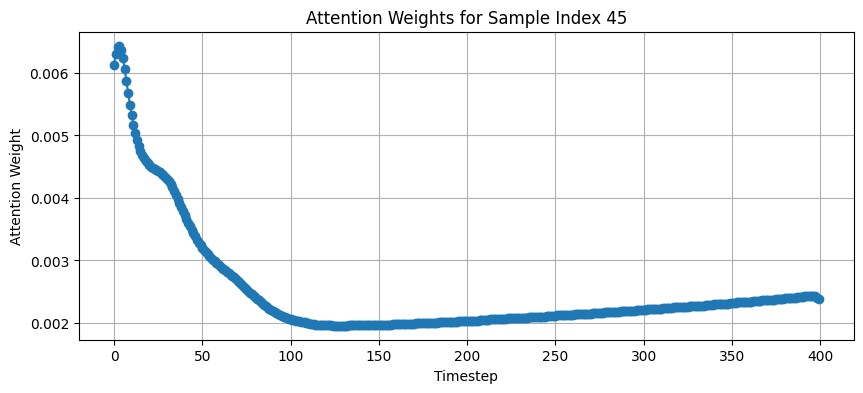

In [30]:
import matplotlib.pyplot as plt

# Convert attention weights to CPU and squeeze
attn_vals = attn_weights.squeeze().cpu().numpy()  # shape: [seq_len]

plt.figure(figsize=(10, 4))
plt.plot(attn_vals, marker='o')
plt.title(f"Attention Weights for Sample Index {sample_idx}")
plt.xlabel("Timestep")
plt.ylabel("Attention Weight")
plt.grid(True)
plt.show()


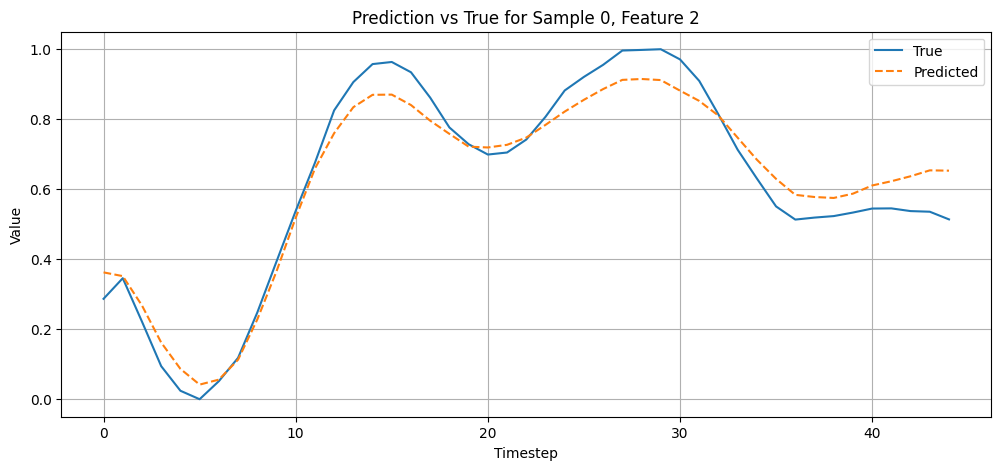

In [23]:
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
model.eval()

all_preds = []
all_actuals = []

with torch.no_grad():
    for x_seq_batch, x_angle_batch, y_target_batch in val_loader:
        pred_batch, _ = model(x_seq_batch, x_angle_batch)
        all_preds.append(pred_batch.cpu())
        all_actuals.append(y_target_batch.cpu())

# Concatenate all batches
all_preds = torch.cat(all_preds, dim=0)   # shape: [val_size, seq_len, features]
all_actuals = torch.cat(all_actuals, dim=0)

# For plotting, you can pick a feature index to visualize
feature_idx = 2  # first output feature
seq_idx = 0      # optional: you can loop over multiple sequences

plt.figure(figsize=(12, 5))

# Example: plot first sequence in validation set
plt.plot(all_actuals[seq_idx, :, feature_idx], label="True")
plt.plot(all_preds[seq_idx, :, feature_idx], label="Predicted", linestyle='--')
plt.title(f"Prediction vs True for Sample {seq_idx}, Feature {feature_idx}")
plt.xlabel("Timestep")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()



In [20]:
# Core libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# XAI / Attribution
from captum.attr import IntegratedGradients
import shap

# --- 1. Define train/val/test indices ---
# Assuming train/val split is already done
# We'll define test indices as the validation set here
val_indices = val_dataset.indices if hasattr(val_dataset, 'indices') else list(range(train_size, N_EXPERIMENTS))
train_indices = train_dataset.indices if hasattr(train_dataset, 'indices') else list(range(train_size))

# Convert indices to tensors for easier slicing
train_idx = np.array(train_indices)
test_idx = np.array(val_indices)

X_seq_test = X_seq[test_idx]
X_angle_test = X_angle[test_idx]
Y_target_test = Y_target[test_idx]

# -------------------------------
# 2. Saliency
# -------------------------------
def compute_saliency(x_seq, x_angle, model, sample_idx, target_seq_idx, target_feature_idx):
    x_seq_s = x_seq[sample_idx:sample_idx+1].clone().detach().to(device)
    x_seq_s.requires_grad = True
    x_angle_s = x_angle[sample_idx:sample_idx+1].clone().detach().to(device)
    x_angle_s.requires_grad = True
    out = model(x_seq_s, x_angle_s)
    target = out[0, target_seq_idx, target_feature_idx]
    model.zero_grad()
    target.backward()
    saliency = x_seq_s.grad.data
    importance_per_timestep = saliency.abs().sum(dim=2).squeeze(0)
    return importance_per_timestep.cpu().numpy(), out.detach().cpu().numpy()[0]

# -------------------------------
# 3. Integrated Gradients
# -------------------------------
def compute_integrated_gradients(x_seq, x_angle, model, sample_idx, target_seq_idx, target_feature_idx, steps=50):
    ig = IntegratedGradients(model)
    x_seq_s = x_seq[sample_idx:sample_idx+1].clone().detach().to(device)
    x_angle_s = x_angle[sample_idx:sample_idx+1].clone().detach().to(device)
    attr_seq, _ = ig.attribute((x_seq_s, x_angle_s),
                               target=target_seq_idx * Y_target.shape[2] + target_feature_idx,
                               n_steps=steps)
    importance_per_timestep = attr_seq.abs().sum(dim=2).squeeze(0).cpu().numpy()
    out = model(x_seq_s, x_angle_s).detach().cpu().numpy()[0]
    return importance_per_timestep, out

# -------------------------------
# 4. Occlusion
# -------------------------------
def compute_occlusion(x_seq, x_angle, model, sample_idx, target_seq_idx, target_feature_idx):
    x_orig = x_seq[sample_idx:sample_idx+1].clone().detach().to(device)
    base_out = model(x_orig, x_angle[sample_idx:sample_idx+1])[0, target_seq_idx, target_feature_idx]
    importances = []
    for t in range(x_orig.shape[1]):
        x_masked = x_orig.clone()
        x_masked[0, t, :] = 0
        masked_out = model(x_masked, x_angle[sample_idx:sample_idx+1])[0, target_seq_idx, target_feature_idx]
        importances.append((base_out - masked_out).abs().item())
    out = model(x_orig, x_angle[sample_idx:sample_idx+1]).detach().cpu().numpy()[0]
    return np.array(importances), out

# -------------------------------
# 5. Kernel SHAP
# -------------------------------
# Use a small subset of the training data as background
background_size = min(50, len(train_dataset))
background_idx = np.random.choice(len(train_idx), background_size, replace=False)
background_seq = X_seq[train_idx][background_idx].cpu().numpy()
background_angle = X_angle[train_idx][background_idx].cpu().numpy()

bg_flat = np.concatenate([
    background_seq.reshape(background_size, -1),
    background_angle.reshape(background_size, -1)
], axis=1)

def model_predict_np(seq_np, angle_np):
    seq_t = torch.from_numpy(seq_np).float().to(device)
    angle_t = torch.from_numpy(angle_np).float().to(device)
    with torch.no_grad():
        out = model(seq_t, angle_t)
    return out.cpu().numpy()

def make_shap_predict_for_target(target_seq_idx, target_feature_idx):
    def f(z):
        num_seq_feats = background_seq.shape[1]*background_seq.shape[2]
        seq_part = z[:, :num_seq_feats].reshape(-1, background_seq.shape[1], background_seq.shape[2])
        angle_part = z[:, num_seq_feats:]
        return model_predict_np(seq_part, angle_part)[:, target_seq_idx, target_feature_idx]
    return f

kernel_explainer = None
current_target = (None, None)

def compute_kernel_shap(x_seq, x_angle, target_seq_idx, target_feature_idx, nsamples=100):
    global kernel_explainer, current_target
    if kernel_explainer is None or current_target != (target_seq_idx, target_feature_idx):
        f = make_shap_predict_for_target(target_seq_idx, target_feature_idx)
        kernel_explainer = shap.KernelExplainer(f, bg_flat)
        current_target = (target_seq_idx, target_feature_idx)

    seq_np = x_seq.cpu().numpy().reshape(1, -1)
    angle_np = x_angle.cpu().numpy().reshape(1, -1)
    instance_flat = np.concatenate([seq_np, angle_np], axis=1)
    shap_values = kernel_explainer.shap_values(instance_flat, nsamples=nsamples)[0]
    num_seq_feats = background_seq.shape[1]*background_seq.shape[2]
    seq_shap = shap_values[:num_seq_feats].reshape(background_seq.shape[1], background_seq.shape[2])
    importance_per_timestep = np.abs(seq_shap).sum(axis=1)
    return importance_per_timestep, model_predict_np(x_seq.cpu().numpy(), x_angle.cpu().numpy())[0]

# -------------------------------
# 6. Plotting + Widgets
# -------------------------------
def plot_xai_with_shap(sample_idx, target_seq_idx, target_feature_idx, top_k=5, method='Kernel SHAP'):
    if method == 'Kernel SHAP':
        importance, predictions_np = compute_kernel_shap(
            X_seq_test[sample_idx:sample_idx+1],
            X_angle_test[sample_idx:sample_idx+1],
            target_seq_idx,
            target_feature_idx,
            nsamples=200
        )
    elif method == 'Saliency':
        importance, predictions_np = compute_saliency(X_seq_test, X_angle_test, model, sample_idx, target_seq_idx, target_feature_idx)
    elif method == 'Integrated Gradients':
        importance, predictions_np = compute_integrated_gradients(X_seq_test, X_angle_test, model, sample_idx, target_seq_idx, target_feature_idx)
    elif method == 'Occlusion':
        importance, predictions_np = compute_occlusion(X_seq_test, X_angle_test, model, sample_idx, target_seq_idx, target_feature_idx)
    else:
        raise ValueError(f"Unknown method {method}")

    top_timesteps = np.argsort(importance)[-top_k:][::-1]

    plt.figure(figsize=(12,4))
    plt.plot(importance, marker='o', label=f'{method} importance')
    plt.scatter(top_timesteps, importance[top_timesteps], s=150, color='red', label='Top timesteps')
    plt.xlabel("Timestep")
    plt.ylabel("Importance")
    plt.title(f"{method} for Sample {sample_idx}, Output [{target_seq_idx}, {target_feature_idx}]")
    plt.legend()
    plt.show()

    true_np = Y_target_test[sample_idx].cpu().numpy()
    PRED, FEAT = true_np.shape
    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    axes = axes.flatten()
    x_axis = np.arange(PRED)
    for i in range(FEAT):
        ax = axes[i]
        ax.plot(x_axis, true_np[:, i], label='True', marker='o', linestyle='-')
        ax.plot(x_axis, predictions_np[:, i], label='Pred', marker='x', linestyle='--')
        ax.set_title(f'Feature {i}')
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.suptitle(f'Sample {sample_idx}', y=1.02)
    plt.show()

# Widgets
sample_slider = widgets.IntSlider(min=0, max=len(X_seq_test)-1, description='Sample idx')
seq_slider = widgets.IntSlider(min=0, max=Y_target_test.shape[1]-1, description='Output seq idx')
feature_slider = widgets.IntSlider(min=0, max=Y_target_test.shape[2]-1, description='Output feat idx')
topk_slider = widgets.IntSlider(min=1, max=X_seq_test.shape[1], value=5, description='Top K')
method_dropdown = widgets.Dropdown(options=['Saliency', 'Integrated Gradients', 'Occlusion', 'Kernel SHAP'],
                                   value='Saliency', description='Method')

ui = widgets.VBox([sample_slider, seq_slider, feature_slider, topk_slider, method_dropdown])
out = widgets.interactive_output(plot_xai_with_shap, {
    'sample_idx': sample_slider,
    'target_seq_idx': seq_slider,
    'target_feature_idx': feature_slider,
    'top_k': topk_slider,
    'method': method_dropdown
})
display(ui, out)


Output()